In [171]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [172]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'test': 1}

In [173]:
TEST_NUM = OPTIONS['test']
PATH     = f'../files/test{TEST_NUM}'
PATH

'../files/test1'

In [174]:
TARGET_VAR  = 'pitch'
LIMITS      = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits')
STATIC_LIMITS  = LIMITS.get('static')
DYNAMIC_LIMITS = LIMITS.get('dynamic')

print(LIMITS)
print(STATIC_LIMITS)
print(DYNAMIC_LIMITS)

{'dynamic': [100, 500], 'static': [1000, 3500]}
[1000, 3500]
[100, 500]


# IMPORTANDO DADOS

In [175]:
df = pd.read_csv(f'{PATH}/target/data.csv')
df

,pitch,wy,tmp,time,wz,roll,ax,wx,az,ay,yaw
0,1370,1361,62.4,0.000000,6590,-142,1711,28573,995410,27616,246089
1,1370,1361,62.4,0.056952,6590,-142,1711,28573,995410,27616,246089
2,1380,-12093,62.4,0.155965,22999,-147,5758,-20713,996587,24116,246095
3,1378,47959,62.3,0.260658,22796,-146,5727,19151,995688,31804,246095
4,1377,-21138,62.7,0.364186,3628,-145,-2744,-16431,993703,24638,246096
...,...,...,...,...,...,...,...,...,...,...,...
37051,1834,-66805,62.1,3705.261301,-11674,2159,-60165,-26508,1006441,35540,239179
37052,1837,95291,62.2,3705.360156,-23432,2163,-16952,-5040,990582,37341,239179
37053,1839,12306,62.3,3705.451226,2070,2164,-30830,-157,994211,26586,239177
37054,1843,18531,62.3,3705.561126,-23840,2165,-37301,38985,995570,28497,239177


- Convertendo pra radianos

In [176]:
def convertAxis(df):
    g_mpss = 9.80665
    
    for col in ['ax', 'ay', 'az']:
        df[col] = (df[col] / 1000000.0) * g_mpss

    for col in ['wx', 'wy', 'wz']:
        df[col] = df[col] / 100000.0
    
    for col in ['pitch', 'roll', 'yaw']:
        df[col] = df[col] / 1000.0

    return df


df = convertAxis(df)
df.head()

,pitch,wy,tmp,time,wz,roll,ax,wx,az,ay,yaw
0,1.370,0.01361,62.4,0.000000,0.06590,-0.142,0.016779,0.28573,9.761637,0.270820,246.089
1,1.370,0.01361,62.4,0.056952,0.06590,-0.142,0.016779,0.28573,9.761637,0.270820,246.089
2,1.380,-0.12093,62.4,0.155965,0.22999,-0.147,0.056467,-0.20713,9.773180,0.236497,246.095
3,1.378,0.47959,62.3,0.260658,0.22796,-0.146,0.056163,0.19151,9.764364,0.311891,246.095
4,1.377,-0.21138,62.7,0.364186,0.03628,-0.145,-0.026909,-0.16431,9.744898,0.241616,246.096


- Formatando as colunas pra ficar igual a de referência

In [177]:
def switchColumns(df, column1, column2):
    df[[column1, column2]] = df[[column2, column1]]
    return df

df = switchColumns(df, 'roll', 'pitch')
df = switchColumns(df, 'wy', 'wz')
df = switchColumns(df, 'ay', 'az')

df['wy'] = -df['wy']
df['pitch'] = -df['pitch']

df.head()

,pitch,wy,tmp,time,wz,roll,ax,wx,az,ay,yaw
0,0.142,-0.06590,62.4,0.000000,0.01361,1.370,0.016779,0.28573,0.270820,9.761637,246.089
1,0.142,-0.06590,62.4,0.056952,0.01361,1.370,0.016779,0.28573,0.270820,9.761637,246.089
2,0.147,-0.22999,62.4,0.155965,-0.12093,1.380,0.056467,-0.20713,0.236497,9.773180,246.095
3,0.146,-0.22796,62.3,0.260658,0.47959,1.378,0.056163,0.19151,0.311891,9.764364,246.095
4,0.145,-0.03628,62.7,0.364186,-0.21138,1.377,-0.026909,-0.16431,0.241616,9.744898,246.096


In [178]:
removed = df[df.duplicated(subset=['time'], keep='first')]
df      = df.drop_duplicates(subset=['time'], keep='first')
removed

,pitch,wy,tmp,time,wz,roll,ax,wx,az,ay,yaw
5,0.145,0.17844,62.4,0.0,-0.46282,1.376,-0.004982,0.44283,0.191769,9.755940,246.092
35231,-2.155,-0.27613,62.3,0.0,0.09343,1.841,-0.377438,0.10820,0.285619,9.768414,239.584


# VISUALIZAÇÃO DE VARIÁVEIS

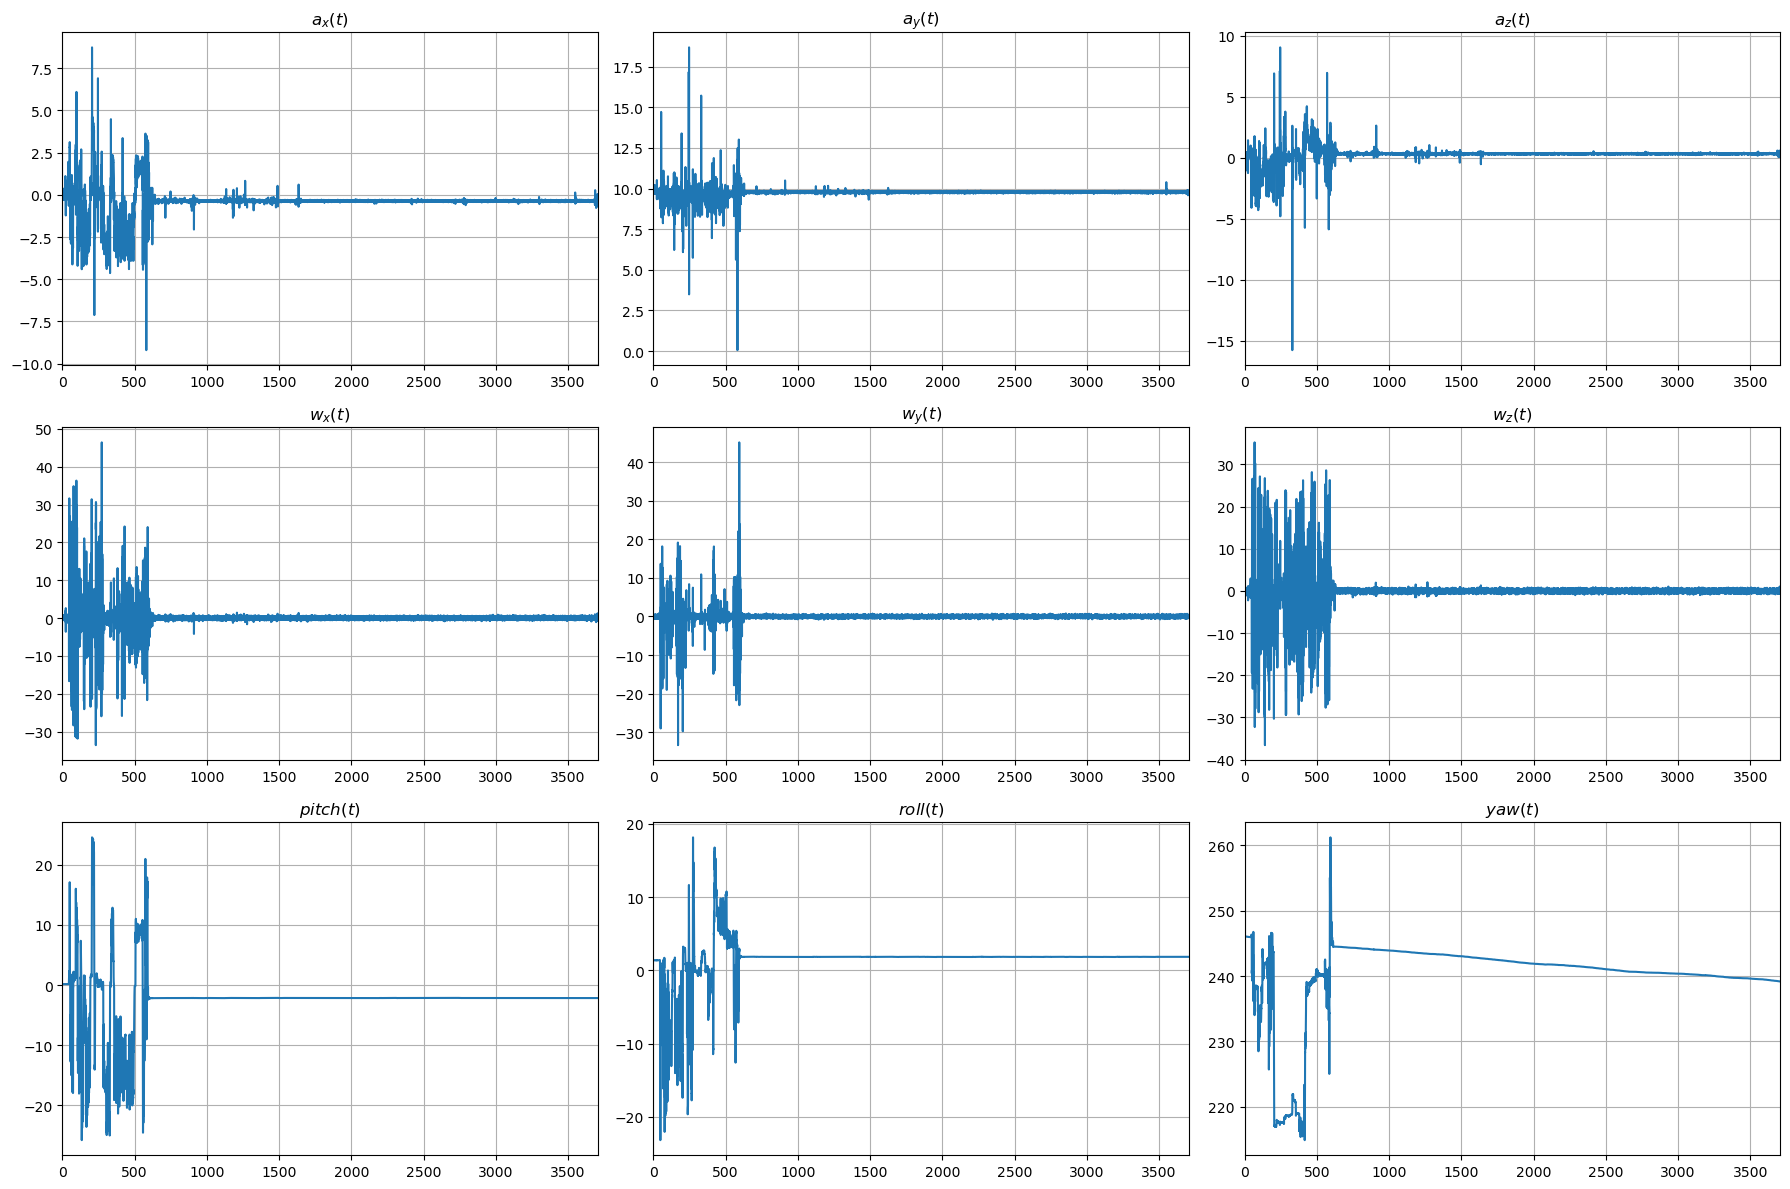

In [179]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

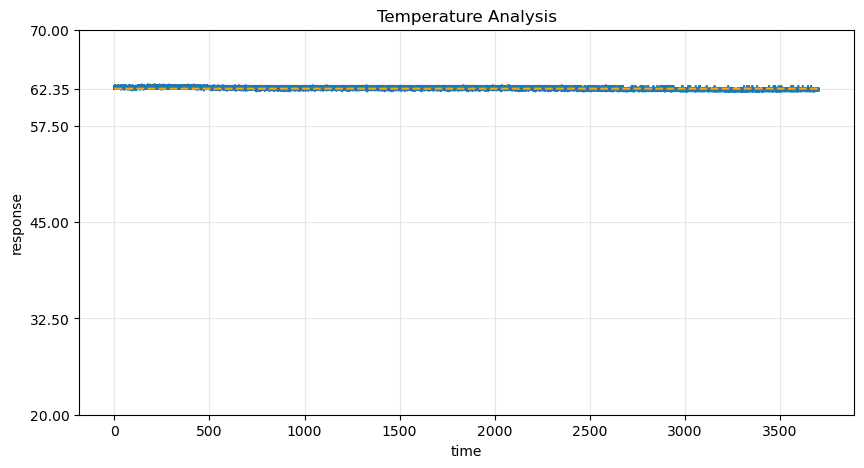

In [180]:
time = df.time.values
temp = df.tmp.values[:-100].mean()

plt.figure(figsize=(10, 5))
plt.plot(time, df.tmp)
plt.plot(time, temp*np.ones_like(time), '--', color='orange')
plt.grid(alpha=0.3); plt.xlabel('time'); plt.ylabel('response')
plt.yticks(list(np.linspace(20, 70, 5)) + [temp])
plt.title('Temperature Analysis')
plt.show()

- Juntando Amostragem pelos limites definidos

In [181]:
df_static  = df.loc[(df.time >= STATIC_LIMITS[0]) & (df.time <= STATIC_LIMITS[1])].copy()
df_dynamic = df.loc[(df.time > DYNAMIC_LIMITS[0]) & (df.time <= DYNAMIC_LIMITS[1])].copy() 

df_dynamic['static'] = False
df_static['static']  = True

df_dynamic.loc[:, 'time'] = (df_dynamic.time - df_dynamic.time.values[0])
df_static.loc[:, 'time']  = (df_static.time  - df_static.time.values[0])  + df_dynamic.time.values[-1]

df = pd.concat([df_dynamic, df_static], axis=0, ignore_index=True)
df

,pitch,wy,tmp,time,wz,roll,ax,wx,az,ay,yaw,static
0,7.939,-4.84356,62.4,0.000000,-23.82033,-7.197,1.405646,29.79857,-1.316572,9.598631,232.319,False
1,10.116,-4.18652,62.7,0.110859,-19.93097,-4.417,1.801648,26.69136,-0.581466,9.487257,231.400,False
2,11.756,-0.70288,62.3,0.212989,-13.30208,-2.055,2.068095,23.18623,-0.425383,9.490690,230.690,False
3,12.788,-0.70880,62.7,0.304652,-6.32595,-0.018,2.226011,14.00286,1.362183,10.754561,230.331,False
4,12.614,-1.90195,62.7,0.412388,6.41184,-0.177,2.222256,-6.03546,-0.034431,9.383022,230.280,False
...,...,...,...,...,...,...,...,...,...,...,...,...
28994,-2.162,-0.20057,62.2,2899.439572,-0.40124,1.839,-0.351990,-0.19655,0.317176,9.806356,239.615,True
28995,-2.160,0.15263,62.0,2899.538391,-0.03069,1.838,-0.379655,-0.04077,0.335123,9.805042,239.616,True
28996,-2.161,0.15371,62.1,2899.631941,0.36778,1.837,-0.369642,-0.07036,0.326238,9.736317,239.616,True
28997,-2.162,0.03562,62.2,2899.740079,-0.32986,1.835,-0.336741,0.33753,0.311646,9.812877,239.617,True


# AMOSTRAGEM

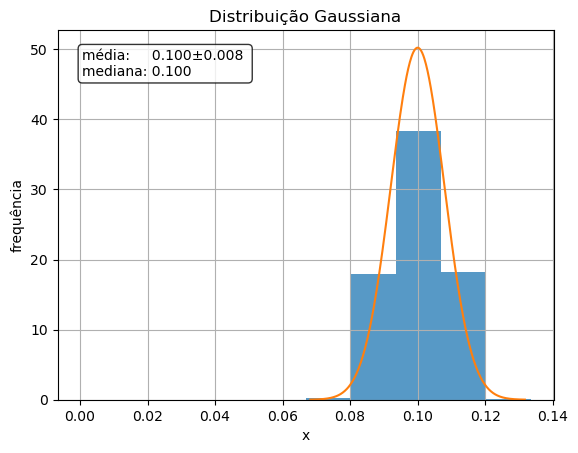

In [182]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time)

In [183]:
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


df = normalizePeriod(df, 'time', dt)
df

,time,pitch,wy,tmp,wz,roll,ax,wx,az,ay,yaw,static
0,0.0,7.939,-4.84356,62.4,-23.82033,-7.197,1.405646,29.79857,-1.316572,9.598631,232.319,False
1,0.1,7.939,-4.84356,62.4,-23.82033,-7.197,1.405646,29.79857,-1.316572,9.598631,232.319,False
2,0.2,10.116,-4.18652,62.7,-19.93097,-4.417,1.801648,26.69136,-0.581466,9.487257,231.400,False
3,0.3,11.756,-0.70288,62.3,-13.30208,-2.055,2.068095,23.18623,-0.425383,9.490690,230.690,False
4,0.4,12.788,-0.70880,62.7,-6.32595,-0.018,2.226011,14.00286,1.362183,10.754561,230.331,False
...,...,...,...,...,...,...,...,...,...,...,...,...
28995,2899.5,-2.162,-0.20057,62.2,-0.40124,1.839,-0.351990,-0.19655,0.317176,9.806356,239.615,True
28996,2899.6,-2.160,0.15263,62.0,-0.03069,1.838,-0.379655,-0.04077,0.335123,9.805042,239.616,True
28997,2899.7,-2.161,0.15371,62.1,0.36778,1.837,-0.369642,-0.07036,0.326238,9.736317,239.616,True
28998,2899.8,-2.162,0.03562,62.2,-0.32986,1.835,-0.336741,0.33753,0.311646,9.812877,239.617,True


# FILTRANDO POR VARIAVEL

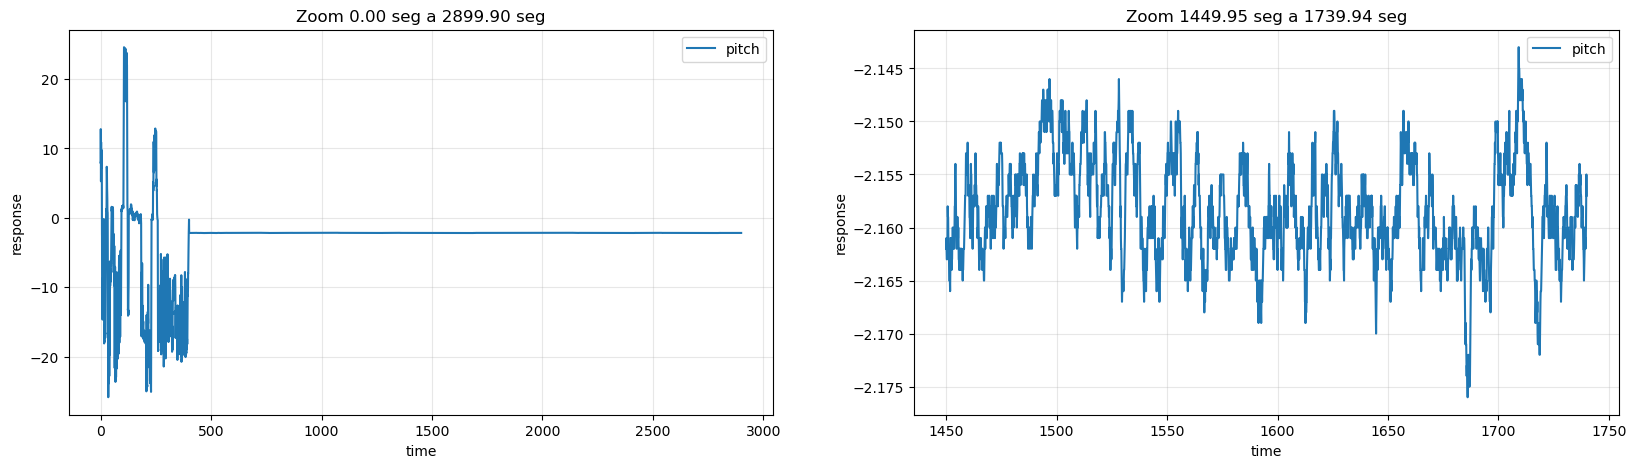

In [184]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df, limits=(0.5, 0.6))

# SALVANDO DADOS

In [185]:
df = df.rename(columns={col: 'target_' + col for col in df.columns if col not in ['time', 'static']})
df

,time,target_pitch,target_wy,target_tmp,target_wz,target_roll,target_ax,target_wx,target_az,target_ay,target_yaw,static
0,0.0,7.939,-4.84356,62.4,-23.82033,-7.197,1.405646,29.79857,-1.316572,9.598631,232.319,False
1,0.1,7.939,-4.84356,62.4,-23.82033,-7.197,1.405646,29.79857,-1.316572,9.598631,232.319,False
2,0.2,10.116,-4.18652,62.7,-19.93097,-4.417,1.801648,26.69136,-0.581466,9.487257,231.400,False
3,0.3,11.756,-0.70288,62.3,-13.30208,-2.055,2.068095,23.18623,-0.425383,9.490690,230.690,False
4,0.4,12.788,-0.70880,62.7,-6.32595,-0.018,2.226011,14.00286,1.362183,10.754561,230.331,False
...,...,...,...,...,...,...,...,...,...,...,...,...
28995,2899.5,-2.162,-0.20057,62.2,-0.40124,1.839,-0.351990,-0.19655,0.317176,9.806356,239.615,True
28996,2899.6,-2.160,0.15263,62.0,-0.03069,1.838,-0.379655,-0.04077,0.335123,9.805042,239.616,True
28997,2899.7,-2.161,0.15371,62.1,0.36778,1.837,-0.369642,-0.07036,0.326238,9.736317,239.616,True
28998,2899.8,-2.162,0.03562,62.2,-0.32986,1.835,-0.336741,0.33753,0.311646,9.812877,239.617,True


In [186]:
df.to_csv('data.csv', index=None)